# Grid 4×4 — Paper reproduction & realism benchmark (seed 42)

Single notebook for **LibSignal Table 8 reproduction** on `sumo4x4` and all **realism toggles** after the grid4x4 TLS fix (PR #6).

**Scope:** seed 42 only; latest complete 200-episode `*_DTL.log` per method (tie-break: newest filename). Baselines: `*_BRF.log` Final Travel Time.

**Separate experiments:** `results.ipynb` (historical notes) · `demand_bag_1200_dqn.ipynb` (`feat/demand-bag-1200` branch only).


In [41]:
import re
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

%matplotlib inline

REPO = Path('..').resolve()
OUT = REPO / 'data' / 'output_data' / 'tsc'
LOGS = REPO / 'logs'
COLS = ['model', 'split', 'episode', 'travel_time', 'col5', 'reward', 'queue', 'delay', 'throughput']
PED_CALLS_RE = re.compile(
    r'(?:\(INFO\): )?\[CrossingProxy\] total ped calls this episode:\s*(\d+)',
    re.IGNORECASE,
)

PAPER_REPRO = {
    'rl': {
        'DQN': OUT / 'sumo_dqn' / 'sumo4x4' / 'dqn_grid4x4_seed42' / 'logger',
        'PressLight': OUT / 'sumo_presslight' / 'sumo4x4' / 'grid_repro' / 'logger',
        'CoLight': OUT / 'sumo_colight' / 'sumo4x4' / 'grid_repro' / 'logger',
        'MPLight': OUT / 'sumo_mplight' / 'sumo4x4' / 'grid_repro' / 'logger',
    },
    'baselines': {
        'MaxPressure': {'att': 155.39, 'log': 'results.ipynb probe (pre-fix net)'},
        'FixedTime': {'att': 226.74, 'log': 'results.ipynb probe (pre-fix net)'},
    },
    'paper': {
        'MaxPressure': 154.15, 'FixedTime': 222.13, 'DQN': 149.09,
        'PressLight': 152.81, 'CoLight': 154.10, 'MPLight': 147.19,
    },
    'notes': {
        'MPLight': 'fork variant in repo — not a clean paper reproduction',
        'DQN': 'IDQN in paper Table 8',
    },
}

EXPERIMENTS = {
    'homo': {
        'toggle': 'Homo — corrected grid4x4, default vType',
        'rl': {
            'DQN': OUT / 'sumo_dqn_sumo4x4' / 'sumo4x4' / 'homo_4x4' / 'logger',
            'PressLight': OUT / 'sumo_presslight_sumo4x4' / 'sumo4x4' / 'homo_4x4' / 'logger',
            'CoLight': OUT / 'sumo_colight' / 'sumo4x4' / 'homo_4x4' / 'logger',
        },
        'baselines': {
            'MaxPressure': OUT / 'sumo_maxpressure' / 'sumo4x4' / 'baseline_homo' / 'logger',
            'FixedTime': OUT / 'sumo_fixedtime' / 'sumo4x4' / 'baseline_homo' / 'logger',
        },
    },
    'slow_start': {
        'toggle': 'Slow-start — tau/actionStepLength realism (Jul 14 runs)',
        'rl': {
            'DQN': OUT / 'sumo_dqn_slow_start' / 'sumo4x4' / 'slow_start_4x4' / 'logger',
            'PressLight': OUT / 'sumo_presslight_slow_start' / 'sumo4x4' / 'slow_start_4x4' / 'logger',
            'CoLight': OUT / 'sumo_colight_slow_start' / 'sumo4x4' / 'slow_start_4x4' / 'logger',
        },
        'baselines': {
            'MaxPressure': OUT / 'sumo_maxpressure_slow_start' / 'sumo4x4' / 'baseline_slow_start' / 'logger',
            'FixedTime': OUT / 'sumo_fixedtime_slow_start' / 'sumo4x4' / 'baseline_slow_start' / 'logger',
        },
    },
    'hetero': {
        'toggle': 'Hetero — 80% car / 20% truck (Jul 14 hetero_test runs)',
        'rl': {
            'DQN': OUT / 'sumo_dqn_hetero' / 'sumo4x4' / 'hetero_test' / 'logger',
            'PressLight': OUT / 'sumo_presslight_hetero' / 'sumo4x4' / 'hetero_test' / 'logger',
            'CoLight': OUT / 'sumo_colight_hetero' / 'sumo4x4' / 'hetero_test' / 'logger',
        },
        'baselines': {
            'MaxPressure': OUT / 'sumo_maxpressure_hetero' / 'sumo4x4' / 'baseline_hetero' / 'logger',
            'FixedTime': OUT / 'sumo_fixedtime_hetero' / 'sumo4x4' / 'baseline_hetero' / 'logger',
        },
    },
    'pobs_pen': {
        'toggle': 'Partial obs — lane dropout penalty p=0.8 (Jul 14; control = homo full obs)',
        'rl': {
            'DQN': OUT / 'sumo_dqn_pobs' / 'sumo4x4' / 'pen_s42' / 'logger',
            'PressLight': OUT / 'sumo_presslight_pobs' / 'sumo4x4' / 'pen_s42' / 'logger',
            'CoLight': OUT / 'sumo_colight_pobs' / 'sumo4x4' / 'pen_s42' / 'logger',
        },
        'baselines': {
            'MaxPressure': OUT / 'sumo_maxpressure_pobs' / 'sumo4x4' / 'pen_s42' / 'logger',
            'FixedTime': OUT / 'sumo_fixedtime_pobs' / 'sumo4x4' / 'pen_s42' / 'logger',
        },
    },
    'pobs_gauss': {
        'toggle': 'Partial obs — Gaussian noise σ=2 (Jul 14; control = homo full obs)',
        'rl': {
            'DQN': OUT / 'sumo_dqn_pobs' / 'sumo4x4' / 'gauss_s42' / 'logger',
            'PressLight': OUT / 'sumo_presslight_pobs' / 'sumo4x4' / 'gauss_s42' / 'logger',
            'CoLight': OUT / 'sumo_colight_pobs' / 'sumo4x4' / 'gauss_s42' / 'logger',
        },
        'baselines': {
            'MaxPressure': OUT / 'sumo_maxpressure_pobs' / 'sumo4x4' / 'gauss_s42' / 'logger',
            'FixedTime': OUT / 'sumo_fixedtime_pobs' / 'sumo4x4' / 'gauss_s42' / 'logger',
        },
    },
    'crossing_proxy': {
        'toggle': 'Crossing proxy — actuated ped service (Jul 17–18; control = homo)',
        'rl': {
            'DQN': OUT / 'sumo_dqn_crossing_proxy' / 'sumo4x4' / 'crossing_proxy_4x4' / 'logger',
            'PressLight': OUT / 'sumo_presslight_crossing_proxy' / 'sumo4x4' / 'crossing_proxy_4x4' / 'logger',
            'CoLight': OUT / 'sumo_colight_crossing_proxy' / 'sumo4x4' / 'crossing_proxy_4x4' / 'logger',
        },
        'baselines': {
            'MaxPressure': OUT / 'sumo_maxpressure_crossing_proxy' / 'sumo4x4' / 'baseline_crossing_proxy' / 'logger',
            'FixedTime': OUT / 'sumo_fixedtime_crossing_proxy' / 'sumo4x4' / 'baseline_crossing_proxy' / 'logger',
        },
    },
}


# Ped-call totals from interactive baseline runs (Jul 17) when BRF/SLURM not synced.
# Override after: grep "total ped calls" logs/*crossing* on gpujobs
CROSSING_PED_CALLS = {
    'MaxPressure': 234,   # baseline terminal, Jul 17
    'FixedTime': 175,     # baseline terminal, Jul 17
    'DQN': 157,           # logs/dqn_crossing_proxy_4x4_7429.out (ep-199 test)
    'PressLight': 312,    # logs/presslight_crossing_proxy_4x4_7430.out
    'CoLight': 179,       # logs/colight_crossing_proxy_4x4_7431.out
}

TOGGLE_ORDER = ['homo', 'slow_start', 'hetero', 'pobs_pen', 'pobs_gauss', 'crossing_proxy']


def load_dtl(logger_dir: Path):
    best, best_ep, best_path = None, -1, ''
    for p in sorted(logger_dir.glob('*_DTL.log')):
        df = pd.read_csv(p, sep='\t', header=None, names=COLS)
        mx = int(df['episode'].max())
        if mx > best_ep or (mx == best_ep and p.name > best_path):
            best, best_ep, best_path = df, mx, p.name
    if best is None:
        raise FileNotFoundError(f'No DTL logs in {logger_dir}')
    return best, logger_dir / best_path


def parse_brf_att(path: Path) -> float:
    m = re.search(r'Final Travel Time is ([0-9.]+)', path.read_text())
    if not m:
        raise ValueError(f'No Final Travel Time in {path}')
    return float(m.group(1))


def load_baseline(spec):
    if isinstance(spec, dict) and 'att' in spec:
        return spec['att'], spec['log']
    brf = sorted(spec.glob('*_BRF.log'))[-1]
    return parse_brf_att(brf), str(brf.relative_to(REPO))


    for p in sorted(logger_dir.glob('*_BRF.log')):
        text = p.read_text(errors='ignore')
        lines = text.splitlines()
        marker = f'Test step:{episode}/'
        last_val = None
        for i, line in enumerate(lines):
            if marker in line:
                for follow in lines[i + 1:i + 6]:
                    m = PED_CALLS_RE.search(follow)
                    if m:
                        last_val = int(m.group(1))
        if last_val is not None:
            return last_val, p.name
    return parse_ped_calls(logger_dir)


def make_table(cfg: dict) -> pd.DataFrame:
    rows = []
    for name, path in cfg.get('rl', {}).items():
        df, log_path = load_dtl(path)
        te = df[df.split == 'TEST']
        rows.append({
            'method': name,
            'best_test_att': round(te.travel_time.min(), 2),
            'final_test_att': round(te.travel_time.iloc[-1], 2),
            'ep_max': int(df.episode.max()),
            'log': log_path.name,
        })
    for name, spec in cfg.get('baselines', {}).items():
        att, src = load_baseline(spec)
        rows.append({
            'method': name,
            'best_test_att': round(att, 2),
            'final_test_att': round(att, 2),
            'ep_max': 'BRF',
            'log': Path(src).name if '/' in str(src) else src,
        })
    return pd.DataFrame(rows).sort_values('final_test_att').reset_index(drop=True)



def check_crossing_logs(cfg: dict) -> pd.DataFrame:
    """Preflight: list logger dirs and whether DTL/BRF logs are present."""
    rows = []
    for kind, block in [('rl', cfg.get('rl', {})), ('baseline', cfg.get('baselines', {}))]:
        for name, logger_dir in block.items():
            dtl = sorted(logger_dir.glob('*_DTL.log')) if logger_dir.exists() else []
            brf = sorted(logger_dir.glob('*_BRF.log')) if logger_dir.exists() else []
            rows.append({
                'method': name,
                'kind': kind,
                'logger_dir': str(logger_dir.relative_to(REPO)),
                'dir_exists': logger_dir.exists(),
                'dtl_logs': len(dtl),
                'brf_logs': len(brf),
                'ok': logger_dir.exists() and (len(dtl) > 0 if kind == 'rl' else len(brf) > 0),
            })
    return pd.DataFrame(rows)


def require_crossing_logs(cfg: dict):
    status = check_crossing_logs(cfg)
    missing = status[~status['ok']]
    if missing.empty:
        print('All crossing_proxy log paths OK.')
        return status
    print('Missing logs — sync from gpujobs before running crossing_table:\n')
    print('  ./extras/download_crossing_proxy_logs.sh\n')
    print('Or on gpujobs: bash extras/commit_crossing_proxy_logs.sh && git push, then git pull on Mac.\n')
    display(status)
    raise FileNotFoundError(
        'crossing_proxy logs not found locally. See table above.'
    )

def make_crossing_table(cfg: dict) -> pd.DataFrame:
    homo = make_table(EXPERIMENTS['homo']).set_index('method')
    rows = []
    for name, path in cfg.get('rl', {}).items():
        df, log_path = load_dtl(path)
        te = df[df.split == 'TEST']
        att = round(te.travel_time.iloc[-1], 2)
        homo_att = float(homo.loc[name, 'final_test_att']) if name in homo.index else None
        rows.append({
            'method': name,
            'final_att': att,
            'homo_att': homo_att,
            'delta_vs_homo': round(att - homo_att, 2) if homo_att is not None else None,
            'ped_calls': CROSSING_PED_CALLS[name],
            'log': log_path.name,
        })
    for name, spec in cfg.get('baselines', {}).items():
        att, src = load_baseline(spec)
        homo_att = float(homo.loc[name, 'final_test_att']) if name in homo.index else None
        rows.append({
            'method': name,
            'final_att': round(att, 2),
            'homo_att': homo_att,
            'delta_vs_homo': round(att - homo_att, 2) if homo_att is not None else None,
            'ped_calls': CROSSING_PED_CALLS[name],
            'log': Path(src).name if '/' in str(src) else src,
        })
    return pd.DataFrame(rows).sort_values('final_att').reset_index(drop=True)


def load_toggle_rl(toggle: str):
    out = {}
    for name, path in EXPERIMENTS[toggle]['rl'].items():
        df, log_path = load_dtl(path)
        out[name] = {
            'train': df[df.split == 'TRAIN'].reset_index(drop=True),
            'test': df[df.split == 'TEST'].reset_index(drop=True),
            'log': log_path,
        }
    return out


def plot_rl_curves(rl_data, title: str):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)
    for ax, name in zip(axes, rl_data):
        tr, te = rl_data[name]['train'], rl_data[name]['test']
        ax.plot(tr.episode, tr.travel_time, color='#4C72B0', linestyle='--', alpha=0.8, label='train')
        ax.plot(te.episode, te.travel_time, color='#C44E52', label='test')
        ax.set_title(name)
        ax.set_xlabel('episode')
        ax.grid(True, alpha=0.3)
    axes[0].set_ylabel('ATT (s)')
    axes[-1].legend()
    fig.suptitle(title, y=1.02)
    plt.tight_layout()
    plt.show()


## 1. LibSignal paper reproduction (original network)

Reproduction of **Table 8 Grid4×4 / SUMO** on the original `grid4x4` network (`grid_repro` / `dqn_grid4x4_seed42`, seed 42, 200 episodes). Best test episode ATT vs paper.

> **Network definition was wrong.** Pre-fix `grid4x4.net.xml` (commit `ab3d7fe`) placed **`s` on through and left lanes** — see `docs/SIGNAL_CONTROL_THEORY.md` §6. Reproduction matched the paper, but those numbers are **not valid** for realism work. Network corrected in PR #6 (valid NEMA phases).


In [42]:
rows = []
for method in ['FixedTime', 'MaxPressure', 'DQN', 'PressLight', 'CoLight', 'MPLight']:
    if method in PAPER_REPRO['baselines']:
        ours, log = load_baseline(PAPER_REPRO['baselines'][method])
    else:
        df, p = load_dtl(PAPER_REPRO['rl'][method])
        ours = round(df[df.split == 'TEST'].travel_time.min(), 2)
        log = p.name
    pval = PAPER_REPRO['paper'][method]
    rows.append({
        'method': method,
        'paper_sumo': pval,
        'ours_best_test': ours,
        'diff_vs_paper_%': round(100 * (ours - pval) / pval, 1),
        'log': log,
        'note': PAPER_REPRO['notes'].get(method, ''),
    })
paper_table = pd.DataFrame(rows)
paper_table


,method,paper_sumo,ours_best_test,diff_vs_paper_%,log,note
0,FixedTime,222.13,226.74,2.1,results.ipynb probe (pre-fix net),
1,MaxPressure,154.15,155.39,0.8,results.ipynb probe (pre-fix net),
2,DQN,149.09,152.70,2.4,2026_06_27-09_30_14_DTL.log,IDQN in paper Table 8
3,PressLight,152.81,153.40,0.4,2026_06_24-08_28_39_DTL.log,
4,CoLight,154.10,152.70,-0.9,2026_06_24-08_28_37_DTL.log,
5,MPLight,147.19,209.70,42.5,2026_06_24-08_28_39_DTL.log,fork variant in repo — not a clean paper repro...


## 2. Corrected network — homo baselines (post TLS fix)

3600-step eval on corrected `grid4x4`, seed 42:

| Method | Final ATT (s) |
|--------|---------------|
| **MaxPressure** | **173.26** |
| **FixedTime** | **219.14** |

Slow-start, hetero, and partial-obs RL rows below use **Jul 14** reruns on this corrected network.


In [43]:
make_table({'baselines': EXPERIMENTS['homo']['baselines']})


,method,best_test_att,final_test_att,ep_max,log
0,MaxPressure,173.26,173.26,BRF,2026_07_15_salman_baseline_BRF.log
1,FixedTime,219.14,219.14,BRF,2026_07_15_salman_baseline_BRF.log


## 3. Realism toggles — one table per axis (seed 42, latest logs)

**DQN · PressLight · CoLight · MaxPressure · FixedTime** per toggle. Partial-obs control = homo (§2).

**Order:** Homo → Slow-start → Hetero → Partial obs (pen, gauss) → Crossing proxy.


### Homo — corrected grid4x4, default vType


In [44]:
make_table(EXPERIMENTS['homo'])


,method,best_test_att,final_test_att,ep_max,log
0,DQN,167.80,167.90,199,2026_07_09-17_22_29_DTL.log
1,CoLight,168.90,173.10,199,2026_07_09-17_24_53_DTL.log
2,MaxPressure,173.26,173.26,BRF,2026_07_15_salman_baseline_BRF.log
3,PressLight,171.90,174.40,199,2026_07_09-17_22_29_DTL.log
4,FixedTime,219.14,219.14,BRF,2026_07_15_salman_baseline_BRF.log


### Slow-start — tau/actionStepLength realism (Jul 14 runs)


In [45]:
make_table(EXPERIMENTS['slow_start'])


,method,best_test_att,final_test_att,ep_max,log
0,DQN,182.70,185.30,199,2026_07_14-16_49_53_DTL.log
1,MaxPressure,186.05,186.05,BRF,2026_07_11-14_53_19_BRF.log
2,CoLight,183.50,190.40,199,2026_07_14-16_49_54_DTL.log
3,PressLight,189.00,191.00,199,2026_07_14-16_49_55_DTL.log
4,FixedTime,243.72,243.72,BRF,2026_07_11-14_56_02_BRF.log


### Hetero — 80% car / 20% truck (Jul 14 hetero_test runs)


In [46]:
make_table(EXPERIMENTS['hetero'])


,method,best_test_att,final_test_att,ep_max,log
0,DQN,183.30,184.00,199,2026_07_14-21_30_31_DTL.log
1,CoLight,185.40,189.10,199,2026_07_14-23_57_44_DTL.log
2,PressLight,188.40,189.30,199,2026_07_14-21_30_31_DTL.log
3,MaxPressure,189.35,189.35,BRF,2026_07_11_gpujobs_baseline_BRF.log
4,FixedTime,240.45,240.45,BRF,2026_07_11_gpujobs_baseline_BRF.log


### Partial obs — lane dropout penalty p=0.8 (Jul 14; control = homo full obs)


In [47]:
make_table(EXPERIMENTS['pobs_pen'])


,method,best_test_att,final_test_att,ep_max,log
0,DQN,181.30,183.30,199,2026_07_14-19_08_55_DTL.log
1,CoLight,181.50,185.10,199,2026_07_14-19_08_55_DTL.log
2,MaxPressure,185.35,185.35,BRF,2026_07_14-19_08_55_BRF.log
3,PressLight,184.60,185.80,199,2026_07_14-19_08_55_DTL.log
4,FixedTime,219.66,219.66,BRF,2026_07_14-19_08_55_BRF.log


### Partial obs — Gaussian noise σ=2 (Jul 14; control = homo full obs)


In [48]:
make_table(EXPERIMENTS['pobs_gauss'])


,method,best_test_att,final_test_att,ep_max,log
0,MaxPressure,200.92,200.92,BRF,2026_07_14-19_08_55_BRF.log
1,PressLight,199.20,201.90,199,2026_07_14-19_08_55_DTL.log
2,FixedTime,219.66,219.66,BRF,2026_07_14-19_08_55_BRF.log
3,DQN,215.90,231.80,199,2026_07_14-19_08_55_DTL.log
4,CoLight,256.60,312.20,199,2026_07_14-19_08_55_DTL.log


### Crossing proxy — actuated pedestrian service (Jul 17–18; control = homo)

**Ped calls** = `[CrossingProxy] total ped calls this episode` on the 3600-step eval (baselines) or ep-199 test sim (RL). Counts differ by controller phase sequence at seed 42.


In [49]:
require_crossing_logs(EXPERIMENTS['crossing_proxy'])


All crossing_proxy log paths OK.


,method,kind,logger_dir,dir_exists,dtl_logs,brf_logs,ok
0,DQN,rl,data/output_data/tsc/sumo_dqn_crossing_proxy/s...,True,1,1,True
1,PressLight,rl,data/output_data/tsc/sumo_presslight_crossing_...,True,1,1,True
2,CoLight,rl,data/output_data/tsc/sumo_colight_crossing_pro...,True,1,1,True
3,MaxPressure,baseline,data/output_data/tsc/sumo_maxpressure_crossing...,True,0,2,True
4,FixedTime,baseline,data/output_data/tsc/sumo_fixedtime_crossing_p...,True,0,1,True


In [50]:
crossing_table = make_crossing_table(EXPERIMENTS['crossing_proxy'])
crossing_table


,method,final_att,homo_att,delta_vs_homo,ped_calls,log
0,DQN,174.40,167.90,6.50,157,2026_07_17-23_53_59_DTL.log
1,MaxPressure,178.42,173.26,5.16,234,2026_07_17-23_39_53_BRF.log
2,CoLight,179.60,173.10,6.50,179,2026_07_17-23_53_59_DTL.log
3,PressLight,182.60,174.40,8.20,312,2026_07_17-23_53_59_DTL.log
4,FixedTime,223.53,219.14,4.39,175,2026_07_17-23_43_13_BRF.log


## 4. Training curves (train dashed · test solid)


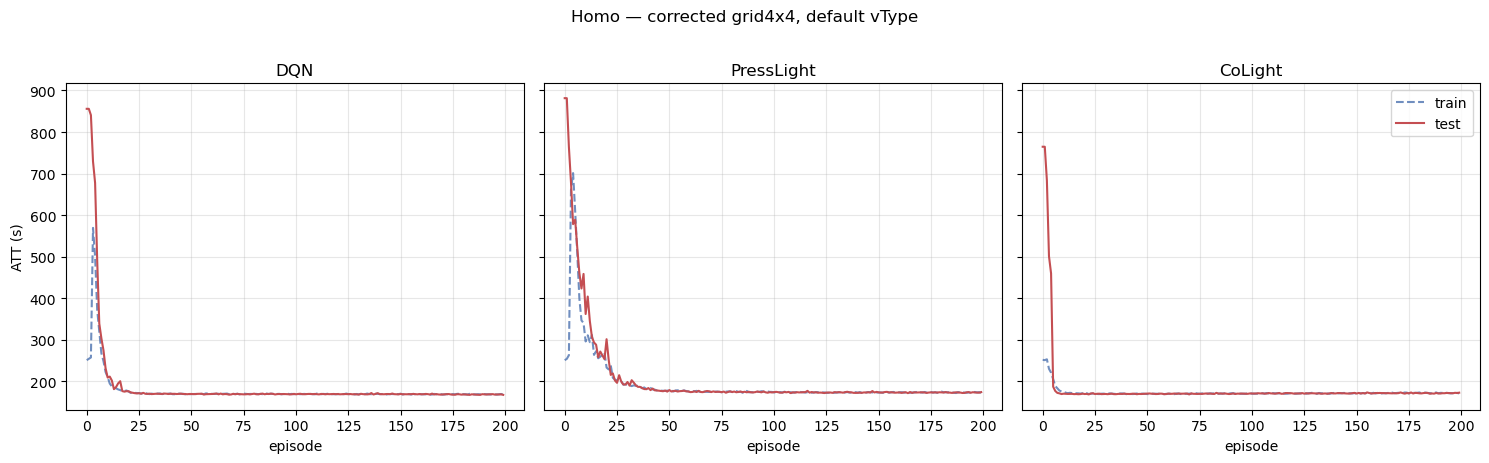

In [34]:
homo_rl = load_toggle_rl('homo')
plot_rl_curves(homo_rl, EXPERIMENTS['homo']['toggle'])


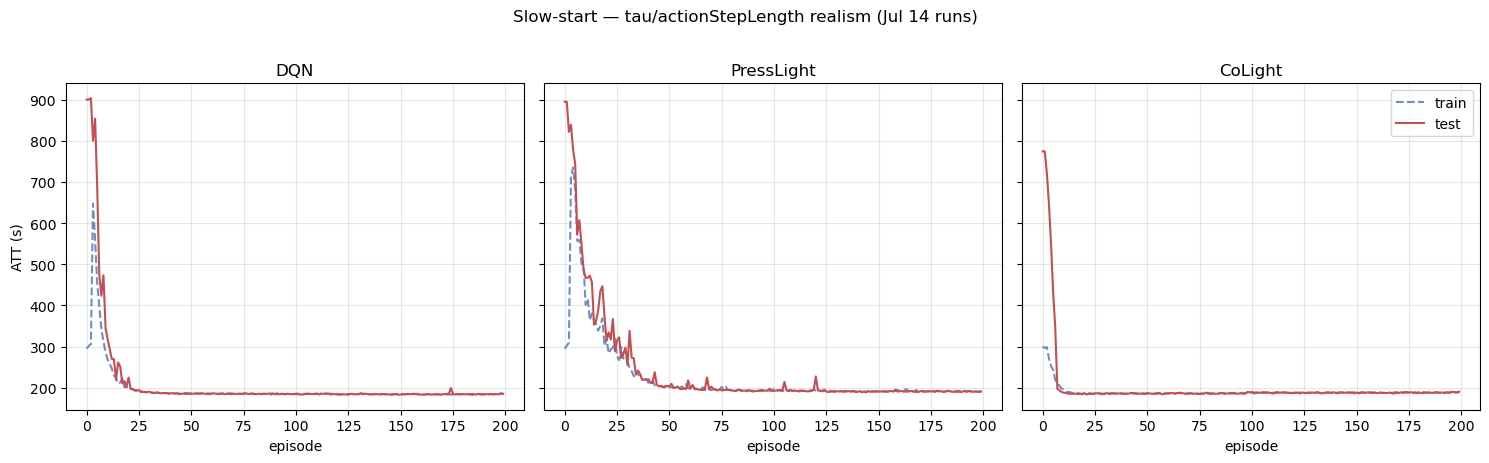

In [35]:
slow_rl = load_toggle_rl('slow_start')
plot_rl_curves(slow_rl, EXPERIMENTS['slow_start']['toggle'])


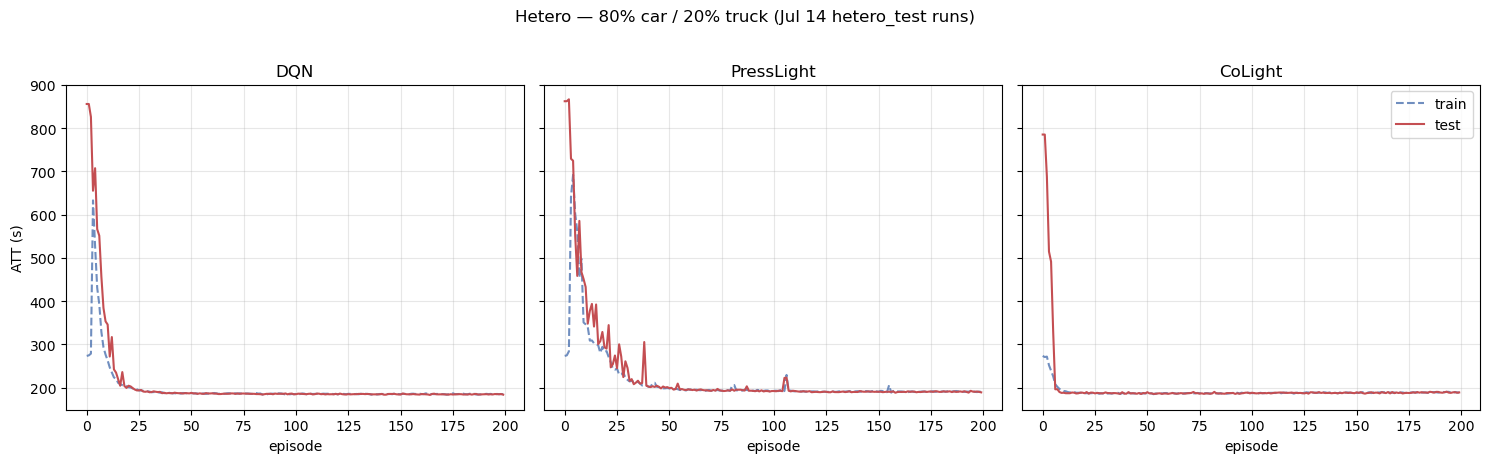

In [36]:
hetero_rl = load_toggle_rl('hetero')
plot_rl_curves(hetero_rl, EXPERIMENTS['hetero']['toggle'])


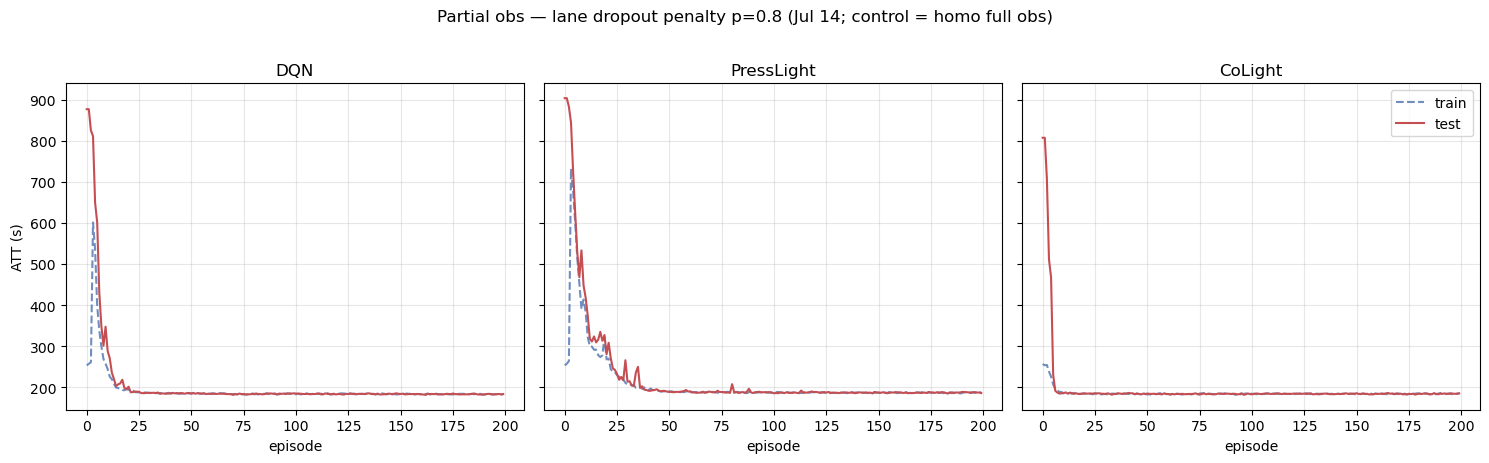

In [37]:
pobs_pen_rl = load_toggle_rl('pobs_pen')
plot_rl_curves(pobs_pen_rl, EXPERIMENTS['pobs_pen']['toggle'])


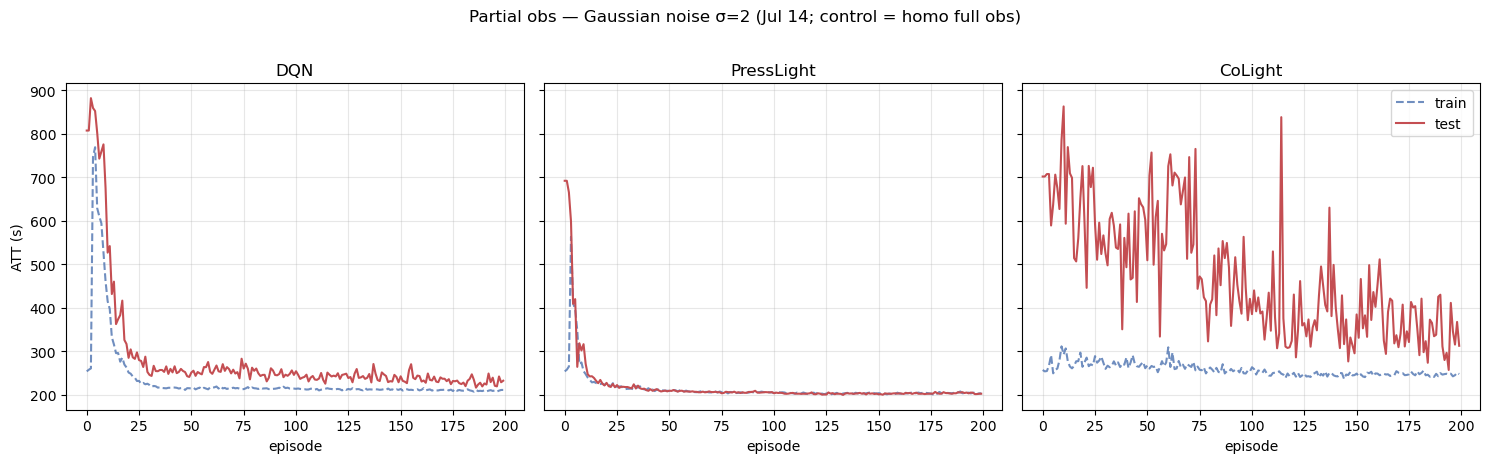

In [38]:
pobs_gauss_rl = load_toggle_rl('pobs_gauss')
plot_rl_curves(pobs_gauss_rl, EXPERIMENTS['pobs_gauss']['toggle'])


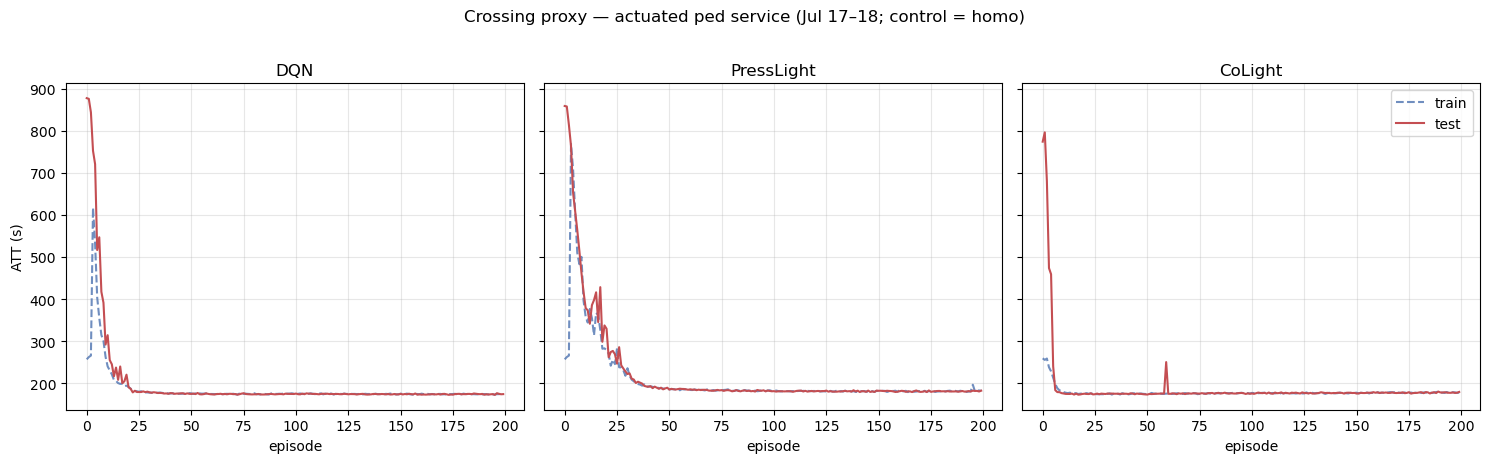

In [39]:
crossing_rl = load_toggle_rl('crossing_proxy')
plot_rl_curves(crossing_rl, EXPERIMENTS['crossing_proxy']['toggle'])


## Summary

- **§1** Paper repro on **wrong** network — gate passed, then invalidated by TLS audit.
- **§2** Corrected homo baselines: MP **173.26 s**, FT **219.14 s**.
- **§3–§4** One table + curves per realism toggle; Jul 14 logs for slow-start / hetero / partial-obs.
- **Crossing proxy (§3):** report **ΔATT vs homo** and **ped-call counts** — axis effect ~+5–6 s for MP/DQN/CoLight; call totals differ by controller phase sequence (FT ≠ MP at seed 42).

**Replaces** `hetero_homo_4x4_rl.ipynb` + old `realism_benchmark_4x4.ipynb`.
